In [4]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
from figures_setup import *
from utils import set_color_code
import palantir

# FOLFIRI treatment of organoids (time course)

## Getting data from arrayExpress: E-MTAB-16836

In [6]:
# Download data from arrayExpress and reassemble anndata object 
from utils_arrayExpress import list_accession_files

accession = "E-MTAB-16836"
download_dir = '../data_arrayExpress'

# List files for the given accession
file_list = list_accession_files(accession, download_dir)
# Show only files ending with palantir.h5ad
palantir_files = file_list[file_list['path'].str.endswith('palantir.h5ad')]
palantir_files

,path,size,type,md5
10,Org_chemo_LM3_palantir.h5ad,728395231,file,None


In [7]:
# Read palantir dataset
file = os.path.join(download_dir, accession, 'Org_chemo_LM3_palantir.h5ad')
adata = sc.read_h5ad(file)
adata

AnnData object with n_obs × n_vars = 1173 × 29483
    obs: 'sample_id', 'Timepoint', 'leiden_0.5', 'HTO_classification', 'HTO_classification.global', 'palantir_pseudotime', 'palantir_entropy'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'gene_trends_clusters'
    uns: 'DM_EigenValues', 'Timepoint_colors', 'neighbors', 'palantir_waypoints', 'sample_id_colors'
    obsm: 'DM_EigenVectors', 'DM_EigenVectors_multiscaled', 'X_pca', 'X_umap', 'branch_masks', 'palantir_fate_probabilities'
    varm: 'PCs', 'gene_trends_Term_0', 'gene_trends_Term_2'
    layers: 'MAGIC_imputed_data'
    obsp: 'DM_Kernel', 'DM_Similarity', 'connectivities', 'distances'

## UMAP representation

In [8]:
# Add time annotation
from utils_chemo_timecourse import color_code
import utils_chemo_timecourse as utils_spec
import utils

utils_spec.add_time(adata)
utils.set_uns_colors(adata, color_code, 'time')

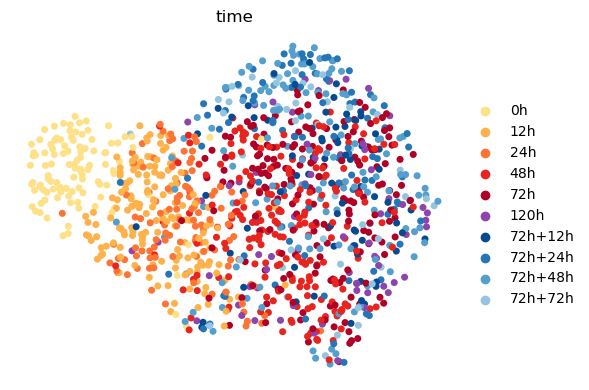

In [9]:
# Annotation UMAP
sc.pl.umap(
    adata,
    color=["time"],
    frameon=False,
    title=None,
    show=False
)

fig = plt.gcf()
fig.set_size_inches(6, 4)
plt.tight_layout()
plt.show()

## Palantir pseudotime

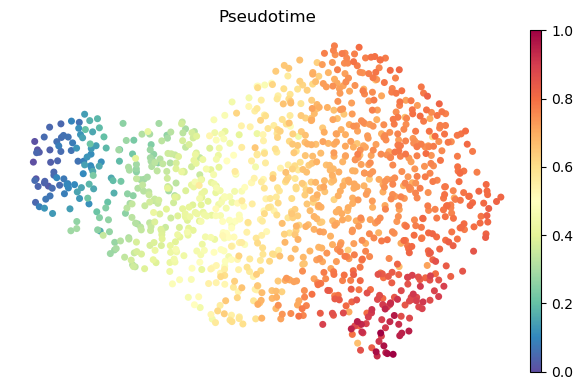

In [10]:
# Annotation UMAP
sc.pl.umap(
    adata,
    color=["palantir_pseudotime"],
    frameon=False,
    title="Pseudotime",
    show=False
)

fig = plt.gcf()
fig.set_size_inches(6, 4)
plt.tight_layout()
plt.show()

## Gene expression UMAP

UMAPs of gene expression patterns:


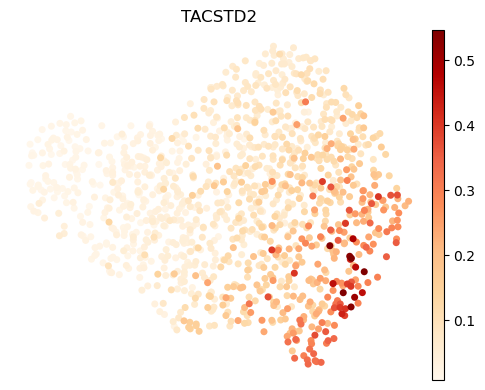

/tmp/ipykernel_789372/3206618596.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


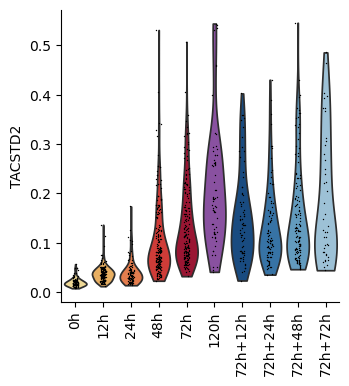

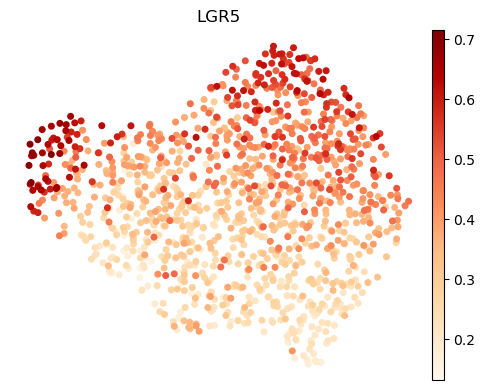

/tmp/ipykernel_789372/3206618596.py:40: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


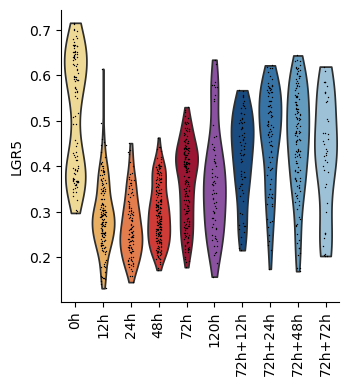

In [11]:
# Features to plot
features = ['TACSTD2', 'LGR5']

# Groupby
groupby = 'time'

# Data layer
layer = 'MAGIC_imputed_data'

# Define plotting parameters
vmax = None
dot_size = 120000 / adata.shape[0]

# Make UMAPs of gene set scores
print("UMAPs of gene expression patterns:")
for feature in features:    
    # Plot on UMAP
    sc.pl.umap(
        adata, 
        color=feature, 
        layer=layer, 
        use_raw=False,
        size=dot_size, 
        cmap='OrRd', 
        vmax=vmax, 
        frameon=False,
        show=False
    )
    fig = plt.gcf()
    fig.set_size_inches(5, 4)
    plt.tight_layout()
    plt.show()

    # Plot as violin plot
    ax = sc.pl.violin(adata, keys=feature, groupby=groupby, 
                 layer=layer, use_raw=False, rotation=90, show=False)
    if ax.legend_ is not None:
        ax.legend_.set_bbox_to_anchor((1.02, 0.9))

    plt.tight_layout()
    plt.show()

## Plotting palantir trajectories

In [12]:
# Pick branch color from color code
branches = ['Term_0', 'Term_2']
branch_color = {
    'Term_0': color_code['time']['colors']['72h'],
    'Term_2': color_code['time']['colors']['72h+12h']
}
# Mapping of interpretable branch names
branch_title = {
    "Term_0": "Treatment",
    "Term_2": "Release"
}

[2026-05-11 14:21:48,777] [INFO    ] Using sparse Gaussian Process since n_landmarks (50) < n_samples (453) and rank = 1.0.
[2026-05-11 14:21:48,779] [INFO    ] Using covariance function Matern52(ls=0.6709485054016113).
[2026-05-11 14:21:48,798] [INFO    ] Computing 50 landmarks with k-means clustering (random_state=42).
[2026-05-11 14:21:50,703] [INFO    ] Sigma interpreted as element-wise standard deviation.
[2026-05-11 14:21:51,211] [INFO    ] Using sparse Gaussian Process since n_landmarks (50) < n_samples (370) and rank = 1.0.
[2026-05-11 14:21:51,213] [INFO    ] Using covariance function Matern52(ls=0.6709485054016113).
[2026-05-11 14:21:51,230] [INFO    ] Computing 50 landmarks with k-means clustering (random_state=42).
[2026-05-11 14:21:51,990] [INFO    ] Sigma interpreted as element-wise standard deviation.


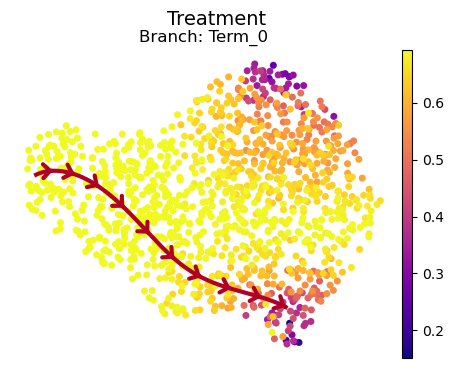

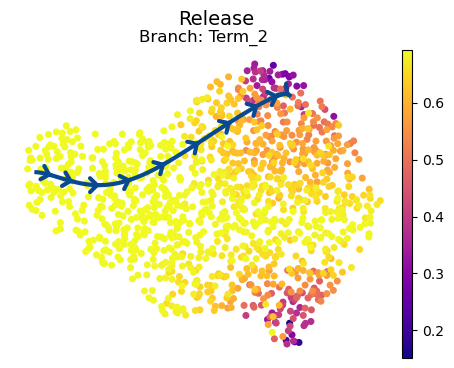

In [13]:
# Palantir branches on UMAP
entropy_cmap = 'plasma'

# Make UMAP plot for each branch
for branch in branches:
    color = 'palantir_entropy'
    palantir.plot.plot_trajectory(
        adata,
        branch, 
        cell_color="palantir_entropy", 
        n_arrows=10, 
        color=branch_color[branch], 
        scanpy_kwargs=dict(cmap=entropy_cmap), 
        arrowprops=dict(arrowstyle="->,head_length=.5,head_width=.5", lw=3),
        lw=3, 
        pseudotime_interval=(0, .9), 
    )
    fig = plt.gcf()
    fig.set_size_inches(5.5, 4)
    fig.suptitle(branch_title[branch], fontsize=14)
    fig.show()

In [14]:
# Compute gene trends
gene_trends = palantir.presults.compute_gene_trends(
    adata,
    expression_key="MAGIC_imputed_data",
)

Term_0
[2026-05-11 14:21:55,815] [INFO    ] Using non-sparse Gaussian Process since n_landmarks (500) >= n_samples (453) and rank = 1.0.
[2026-05-11 14:21:55,816] [INFO    ] Using covariance function Matern52(ls=1.0).
[2026-05-11 14:21:56,797] [INFO    ] Sigma interpreted as element-wise standard deviation.
Term_2
[2026-05-11 14:21:59,979] [INFO    ] Using non-sparse Gaussian Process since n_landmarks (500) >= n_samples (370) and rank = 1.0.
[2026-05-11 14:21:59,979] [INFO    ] Using covariance function Matern52(ls=1.0).
[2026-05-11 14:22:00,494] [INFO    ] Sigma interpreted as element-wise standard deviation.


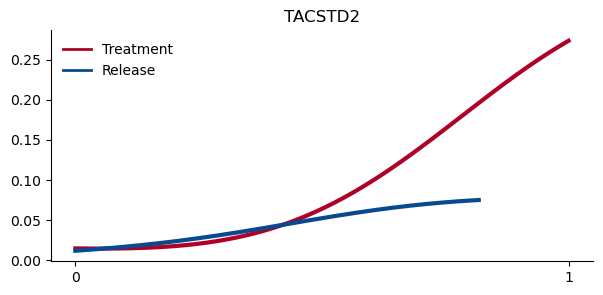

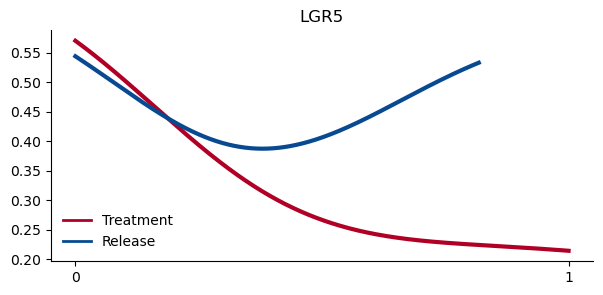

In [15]:
# Visualize gene trends
from matplotlib.lines import Line2D

# Visualize individual genes across branches
genes = ["TACSTD2", "LGR5"]

# Iterate over all genes
for gene in genes:
    # Get palantir figure output
    fig  = palantir.plot.plot_gene_trends(adata, [gene])
    # Get all axes in the figure
    for ax in fig.axes:
        for line in ax.get_lines():
            label = line.get_label()
            # Set line color and width based on branch
            for br, col in branch_color.items():
                if br in label:
                    line.set_color(col)
                    line.set_linewidth(3.0)

    # Extract legend handles and labels for custom legend
    legend_handles = [
        Line2D(
            [0], [0],
            color=branch_color[br],
            lw=2,
            label=branch_title[br]
        )
        for br in branches
    ]

    # Add custom legend to each axis
    for ax in fig.axes:
        ax.legend(
            handles=legend_handles,
            title="",
            frameon=False
        )
    fig = plt.gcf()
    fig.canvas.draw_idle()
    fig.show()

# Session info

The analysis above has been performed using a micromamba environment with the following package versions:

In [16]:
session_info.show()